# Investigacion

## Naturaleza de las series de tiempo

Una serie de tiempo no es simplemente “datos con fechas”, sino una secuencia ordenada en el tiempo donde:
- Existe dependencia temporal (los valores pasados influyen en los futuros).
- Puede haber estacionalidad (patrones que se repiten, ej. consumo eléctrico diario).
- El orden es fundamental: a diferencia de un dataset tabular normal, no puedes barajar los datos sin perder estructura.

Cuando imputamos valores, no podemos tratarlos como faltantes aleatorios de cualquier dataset, porque romperíamos la coherencia temporal.

## Tipos de datos faltantes en una serie de tiempo

- Faltantes puntuales (missing at random) → un par de días, minutos o registros sueltos.
- Faltantes consecutivos cortos (gaps) → huecos de algunos periodos.
- Faltantes largos (bloques enteros) → días, semanas o meses completos sin datos.
- Inicio o fin truncado → cuando la serie no arranca o termina de manera completa.

Cada tipo requiere una estrategia distinta.

## Estrategias de imputacion para series de tiempo

**Métodos simples**
Forward Fill (ffill): rellenar con el último valor conocido.

✅ Bueno para datos estables (ej. sensores).

❌ Puede crear sesgo si hay tendencia.

Backward Fill (bfill): usar el siguiente valor disponible.
Similar limitación que ffill.

**Interpolación temporal**
Lineal: conecta los puntos vecinos.
Polinómica / spline: suaviza, útil cuando la curva es continua.
Interpolación basada en tiempo: ajusta tomando en cuenta los intervalos.

✅ Útil cuando la serie es continua.

❌ No funciona bien con estacionalidad marcada.

**Métodos basados en estacionalidad y tendencia**
Descomposición (STL, aditiva/multiplicativa): separar tendencia, estacionalidad y residuales, imputar en cada componente y recomponer.
Mean/Median por temporada: reemplazar por la media del mismo día/hora en otros periodos.
Ej: faltó el lunes 3pm → reemplazar por el promedio de todos los lunes a las 3pm.


**Modelos estadísticos clásicos**
ARIMA / SARIMA: entrenar un modelo autorregresivo y predecir los valores faltantes.
Kalman Smoothing (State Space Models): muy robusto para imputar porque maneja ruido y tendencia.

✅ Más sofisticado, conserva propiedades de la serie.

**Métodos de Machine Learning / Deep Learning**
KNN Imputer temporal: busca patrones en ventanas similares.
Random Forests o XGBoost: usa variables rezagadas (lags) y exógenas para predecir valores faltantes.
Redes Neuronales Recurrentes (LSTM, GRU): aprenden dependencias largas en el tiempo.

✅ Muy potentes para huecos grandes.
❌ Requieren más datos y recursos.

## Gaps

### ¿Que es un Gap?

Un gap es un hueco o intervalo de datos faltantes en una serie temporal. Puede ser:
- Pequeño y puntual: faltan 1 o pocos registros aislados.
- Corto y consecutivo: faltan varios registros seguidos, pero de poca longitud relativa.
- Largo: un bloque extenso de valores faltantes.
- Irregular/recurrente: aparecen muchos gaps en diferentes partes de la serie.

La clave es que un gap rompe la continuidad de la serie y puede distorsionar el análisis si no se maneja.

### Caracterización general de los gaps

Un gap puede caracterizarse con tres dimensiones:
- Longitud absoluta
- - Número de periodos consecutivos que faltan (ej: 5 horas en una serie horaria).
- Longitud relativa (ratio)
- - Respecto al periodo estacional s (ej: faltan 12 horas en una serie horaria con s=24 → 0.5).
- - Respecto a la longitud total N (ej: faltan 50 puntos en una serie de 5000 → 1%).
- Posición
- - Al inicio, al final o en el medio.

Si se repite siempre en el mismo subperiodo (ej: siempre falta el domingo por la noche).

### Clasificacion de gaps

- Gap pequeño:
gap_length / s < 0.25 (menos de 25% de un ciclo estacional)
→ fácil de imputar con interpolación, ffill/bfill, media estacional.

- Gap moderado:
0.25 ≤ gap_length / s < 0.75
→ requiere métodos que combinen tendencia + estacionalidad (STL, SARIMA).

- Gap largo:
gap_length / s ≥ 0.75
→ se vuelve riesgoso, mejor usar modelos estadísticos (Kalman, ARIMA) o machine learning con lags/exógenas.

- Gap crítico/extenso:
gap_length / N ≥ 20%
→ puede invalidar gran parte del análisis; mejor reconocerlo como “laguna de información” más que imputar.

# Implementacion

## Librerias usadas

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, normaltest, kstest
from tabulate import tabulate

## Funciones usadas

In [102]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [103]:
def resumen_numericas(df):

    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

In [104]:
def graficar_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))

        # Histograma
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Boxplot
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

In [105]:
def contar_na_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None

    # Contar NAs en cada variable numérica
    na_counts = df[numericas].isna().sum()

    return na_counts

In [106]:
def mapa_calor_nulos(df, figsize=(10,6), cmap="viridis"):
    plt.figure(figsize=figsize)
    sns.heatmap(df.isnull(), 
                cbar=False, 
                cmap=cmap, 
                yticklabels=False)
    plt.title("Mapa de calor de valores faltantes", fontsize=14)
    plt.show()

In [107]:
def analizar_gaps(df, fecha_col, freq="D", periodo_estacional=None, mostrar_tabla=True):
    """
    Analiza los datos faltantes en un dataframe de series de tiempo y muestra resumen tabular.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    fecha_col : str
        Nombre de la columna con las fechas.
    freq : str
        Frecuencia esperada de la serie ("D"=diaria, "H"=horaria, etc.).
    periodo_estacional : int, opcional
        Periodo estacional conocido (ej: 7 para diaria con estacionalidad semanal,
        24 para horaria con ciclo diario).
    mostrar_tabla : bool
        Si True, muestra resumen tabular en consola.
    """

    # Asegurar índice temporal
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])
    df = df.set_index(fecha_col).asfreq(freq)

    resultados = {}

    for col in df.columns:
        if df[col].isna().sum() == 0:
            continue

        # Identificar posiciones faltantes
        na_mask = df[col].isna().astype(int)

        # Encontrar huecos consecutivos (gaps)
        df[col + "_gap_id"] = (na_mask.diff().fillna(0) == 1).cumsum() * na_mask

        gaps = df.groupby(col + "_gap_id").size()
        gaps = gaps[gaps.index != 0]  # quitar "no-gap"

        resumen = pd.DataFrame({
            "Variable": col,
            "Inicio": [df.index[df[col + "_gap_id"] == g][0] for g in gaps.index],
            "Fin": [df.index[df[col + "_gap_id"] == g][-1] for g in gaps.index],
            "Duración": gaps.values
        })

        # Clasificación según estacionalidad (si se pasa)
        if periodo_estacional:
            resumen["Ratio estacional"] = resumen["Duración"] / periodo_estacional
            resumen["Clasificación"] = pd.cut(
                resumen["Ratio estacional"],
                bins=[0, 0.25, 0.75, 1.5, np.inf],
                labels=["Pequeño", "Moderado", "Significativo", "Largo"]
            )
        else:
            resumen["Clasificación"] = "Sin periodo definido"

        resultados[col] = resumen

        if mostrar_tabla:
            print(f"\n📌 Gaps en variable: {col}")
            print(tabulate(resumen, headers="keys", tablefmt="pretty", showindex=False))

    return resultados

In [108]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [109]:
def eda(df):
    Summary(df, "data")
    resumen_numericas(df)
    contar_na_numericas(df)
    contar_na_numericas(df)/len(df)
    prueba_normalidad(df)
    graficar_numericas(df)
    mapa_calor_nulos(df)
    

## Cargado y revision de datos

In [110]:
df = pd.read_csv("data.csv")

In [111]:
Summary(df, "data")

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,9,715,0



Encabezado:


,fecha,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
0,2023-01-01,NaN,60.67,0.00,99.68,527.2,NaN,NaN,51.647
1,2023-01-02,NaN,48.96,0.00,100.50,493.7,120.04,50.476,48.778
2,2023-01-03,NaN,48.73,0.00,100.86,487.7,119.11,52.349,48.953
3,2023-01-04,NaN,57.13,0.00,101.74,512.8,120.71,NaN,49.383
4,2023-01-05,NaN,NaN,2.79,101.77,477.4,119.39,NaN,46.964


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha        731 non-null    object 
 1   temperatura  624 non-null    float64
 2   humedad      616 non-null    float64
 3   lluvia_mm    731 non-null    float64
 4   precio       658 non-null    float64
 5   ventas       586 non-null    float64
 6   energia_kwh  671 non-null    float64
 7   sensor_A     612 non-null    float64
 8   sensor_B     635 non-null    float64
dtypes: float64(8), object(1)
memory usage: 51.5+ KB


In [113]:
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")

## Analisis Exploratorio de datos(EDA)

In [114]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
temperatura,624.0,18.004904,6.639764,4.330,11.89750,18.070,24.21500,30.160,44.086469,18.070
humedad,616.0,59.708506,8.938622,40.610,51.69500,59.665,67.52000,77.100,79.898955,59.665
lluvia_mm,731.0,1.754501,1.719964,0.000,0.00000,1.410,2.90000,7.650,2.958275,1.410
precio,658.0,102.162264,3.374867,94.830,99.67000,101.975,104.37250,111.310,11.389727,101.975
ventas,586.0,544.198464,34.067847,464.900,517.50000,545.100,571.05000,642.700,1160.618203,545.100
energia_kwh,671.0,141.981297,11.701740,117.940,131.50000,141.920,151.33500,165.080,136.930723,141.920
sensor_A,612.0,54.918033,3.288326,46.864,52.48875,54.953,57.34525,62.362,10.813090,54.953
sensor_B,635.0,53.407631,3.586204,45.033,50.58850,53.424,56.11300,61.743,12.860859,53.424


In [115]:
contar_na_numericas(df)

temperatura    107
humedad        115
lluvia_mm        0
precio          73
ventas         145
energia_kwh     60
sensor_A       119
sensor_B        96
dtype: int64

In [116]:
contar_na_numericas(df)/len(df)

temperatura    0.146375
humedad        0.157319
lluvia_mm      0.000000
precio         0.099863
ventas         0.198358
energia_kwh    0.082079
sensor_A       0.162791
sensor_B       0.131327
dtype: float64

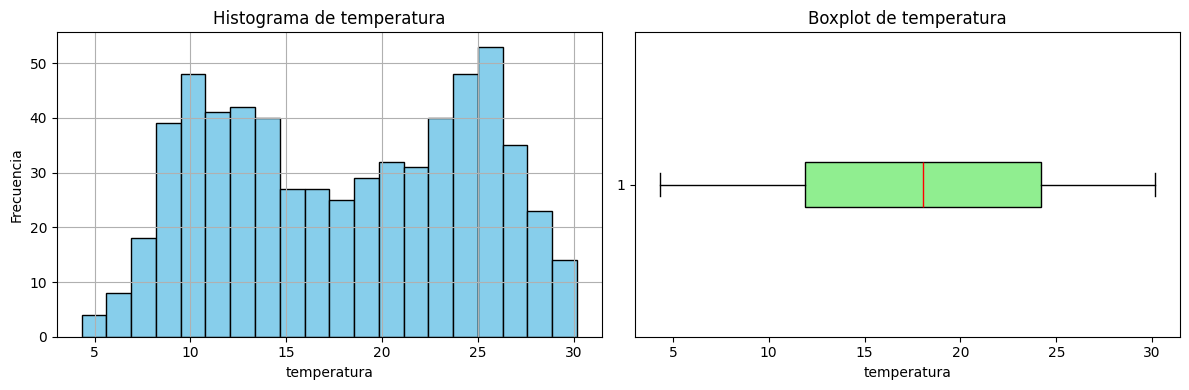

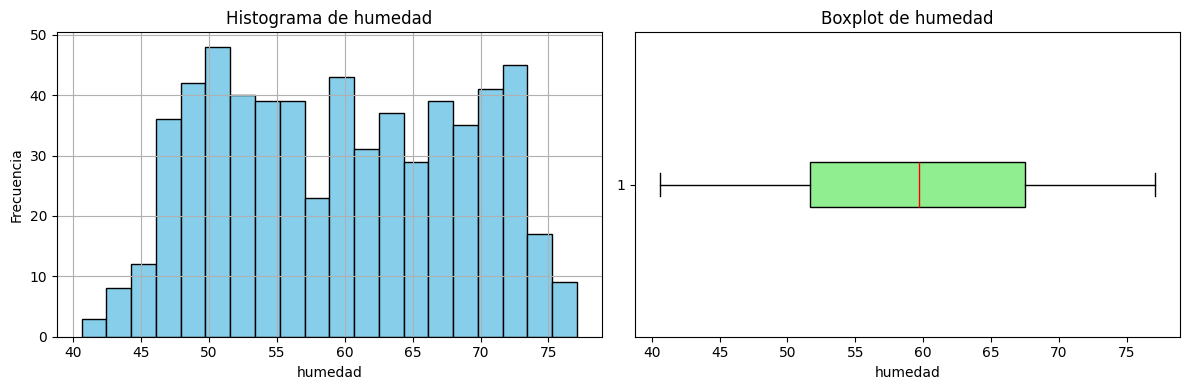

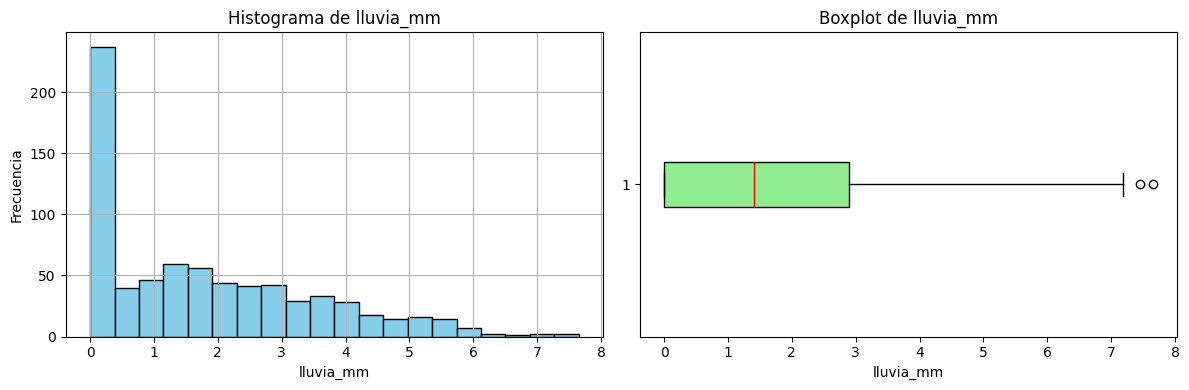

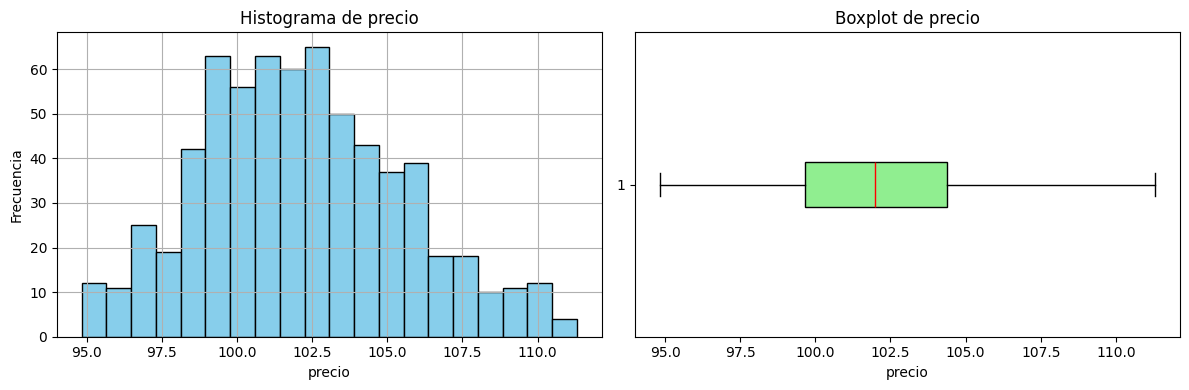

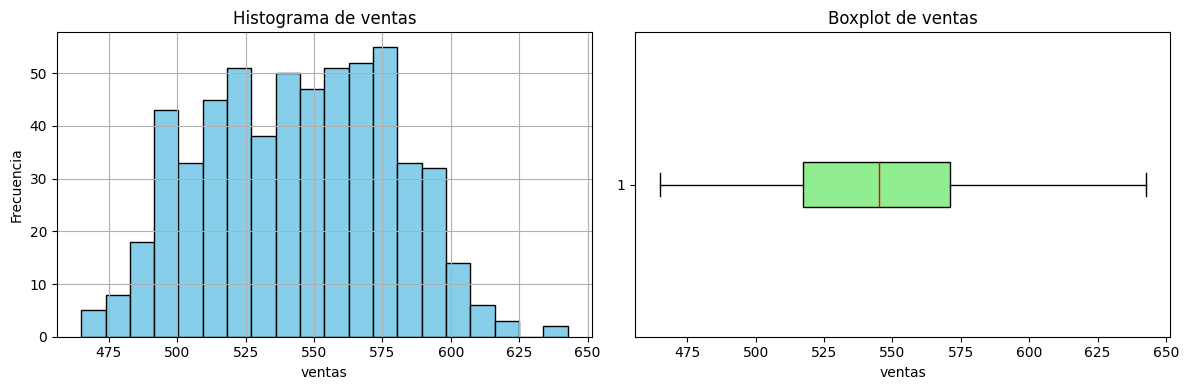

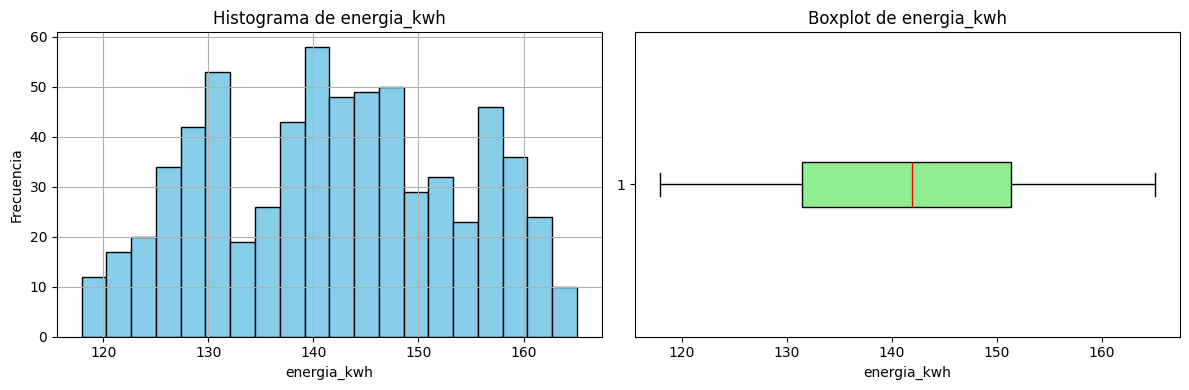

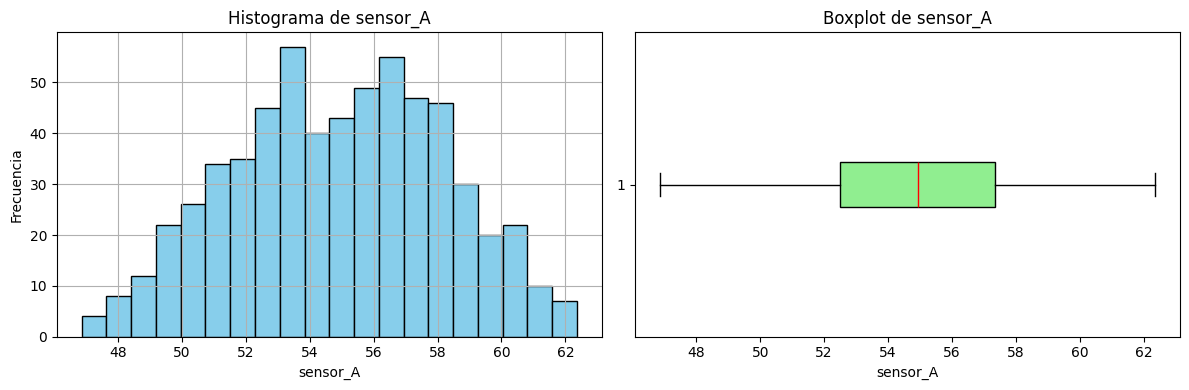

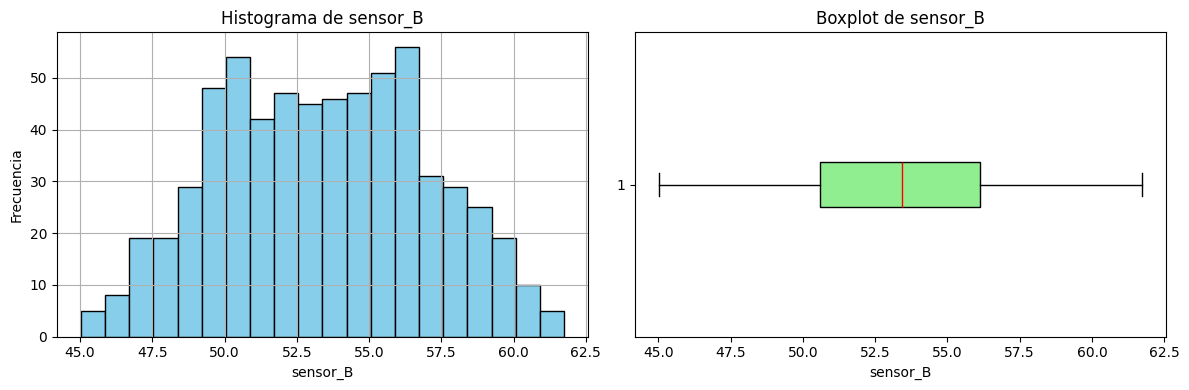

In [117]:
graficar_numericas(df)

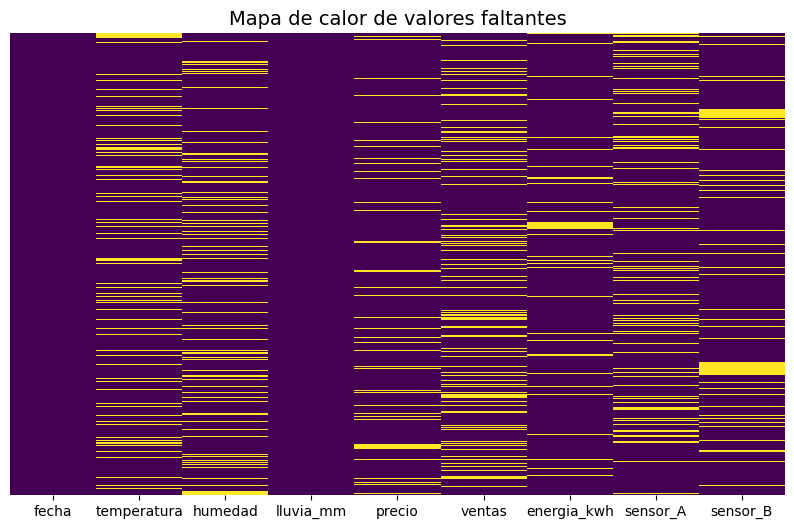

In [118]:
mapa_calor_nulos(df)

In [119]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
0,temperatura,624,4.497637e-14,4.109462e-228,8.917831e-05,False
1,humedad,616,5.052815e-12,1.162274e-84,2.333400e-03,False
2,lluvia_mm,731,2.029689e-22,1.172456e-14,1.532833e-15,False
3,precio,658,4.960803e-05,1.333171e-03,1.569142e-01,False
4,ventas,586,2.113621e-05,4.204641e-09,4.948417e-02,False
5,energia_kwh,671,1.516038e-09,6.413484e-27,3.909482e-03,False
6,sensor_A,612,4.774779e-04,2.912352e-06,1.195304e-01,False
7,sensor_B,635,3.846968e-05,6.846259e-10,1.106053e-01,False


## Clasificacion de datos faltantes

In [120]:
analizar_gaps(df, fecha_col="fecha", freq="D", periodo_estacional= 7)


📌 Gaps en variable: temperatura
+-------------+---------------------+---------------------+----------+---------------------+---------------+
|  Variable   |       Inicio        |         Fin         | Duración |  Ratio estacional   | Clasificación |
+-------------+---------------------+---------------------+----------+---------------------+---------------+
| temperatura | 2023-01-15 00:00:00 | 2023-01-15 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
| temperatura | 2023-01-21 00:00:00 | 2023-01-21 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
| temperatura | 2023-02-23 00:00:00 | 2023-02-23 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
| temperatura | 2023-03-03 00:00:00 | 2023-03-03 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
| temperatura | 2023-03-06 00:00:00 | 2023-03-07 00:00:00 |    2     | 0.2857142857142857  |   Moderado    |
| temperatura | 2023-03-16 00:00:00 | 2023-03-16 00:00:00 |    1     | 0.14285714285714285 |   

{'temperatura':        Variable     Inicio        Fin  Duración  Ratio estacional  \
 0   temperatura 2023-01-15 2023-01-15         1          0.142857   
 1   temperatura 2023-01-21 2023-01-21         1          0.142857   
 2   temperatura 2023-02-23 2023-02-23         1          0.142857   
 3   temperatura 2023-03-03 2023-03-03         1          0.142857   
 4   temperatura 2023-03-06 2023-03-07         2          0.285714   
 ..          ...        ...        ...       ...               ...   
 84  temperatura 2024-11-02 2024-11-02         1          0.142857   
 85  temperatura 2024-11-28 2024-11-28         1          0.142857   
 86  temperatura 2024-12-04 2024-12-04         1          0.142857   
 87  temperatura 2024-12-16 2024-12-16         1          0.142857   
 88  temperatura 2024-12-21 2024-12-22         2          0.285714   
 
    Clasificación  
 0        Pequeño  
 1        Pequeño  
 2        Pequeño  
 3        Pequeño  
 4       Moderado  
 ..           ...  
 84

## Tratamiento de datos faltantes

In [121]:
df = df.set_index("fecha").sort_index()

# a) Forward fill (lleva hacia adelante el último valor observado)
df_ffill = df.fillna(method="ffill")

# b) Backward fill (lleva hacia atrás el siguiente valor observado)
df_bfill = df.fillna(method="bfill")

# c) Interpolación lineal (buena para datos numéricos como temperatura, energía, etc.)
df_interp = df.interpolate(method="linear")

C:\Users\migue\AppData\Local\Temp\ipykernel_12632\2428954663.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method="ffill")
C:\Users\migue\AppData\Local\Temp\ipykernel_12632\2428954663.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method="bfill")


In [122]:
# Interpolación con método de tiempo (mejor si el índice es datetime)
df_time_interp = df.interpolate(method="time")

# Interpolación polinómica (para suavizar tendencias curvas)
df_poly = df.interpolate(method="polynomial", order=2)

## verificacion final de los datos

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,8,9,0



Encabezado:


,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
fecha,,,,,,,,
2023-01-01,NaN,60.67,0.00,99.68,527.2,NaN,NaN,51.647
2023-01-02,NaN,48.96,0.00,100.50,493.7,120.04,50.476,48.778
2023-01-03,NaN,48.73,0.00,100.86,487.7,119.11,52.349,48.953
2023-01-04,NaN,57.13,0.00,101.74,512.8,120.71,52.349,49.383
2023-01-05,NaN,57.13,2.79,101.77,477.4,119.39,52.349,46.964


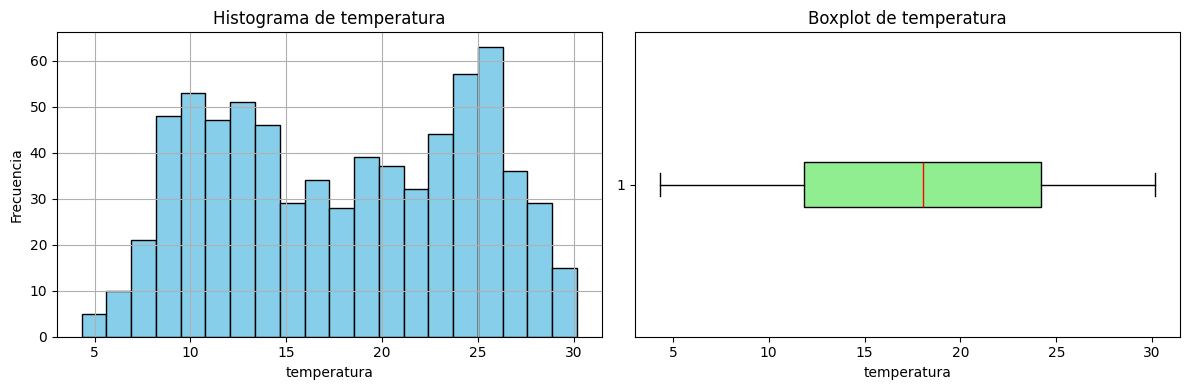

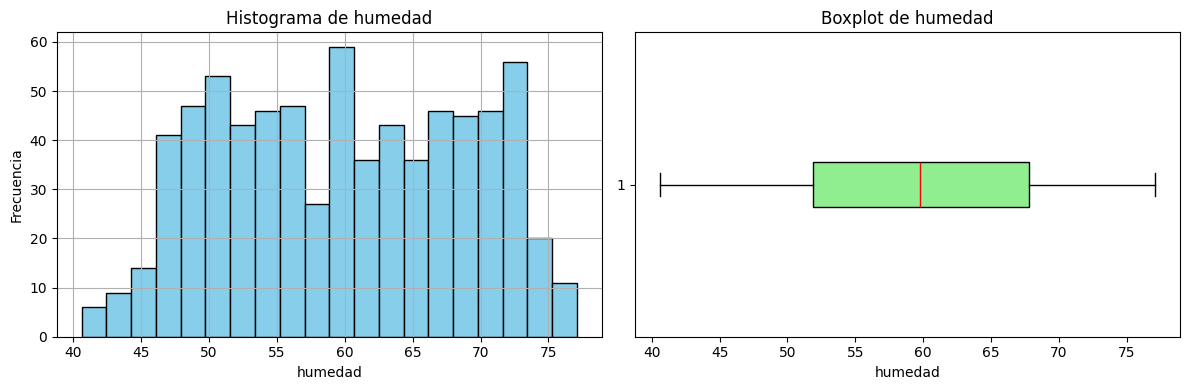

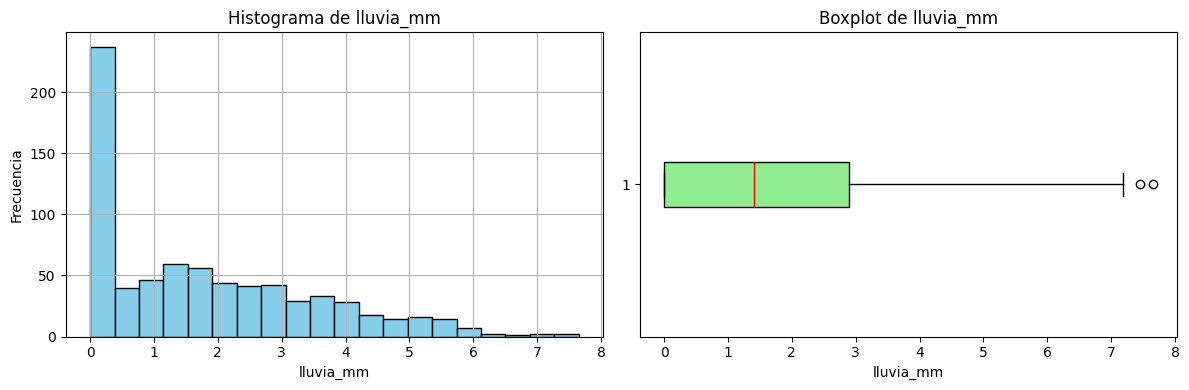

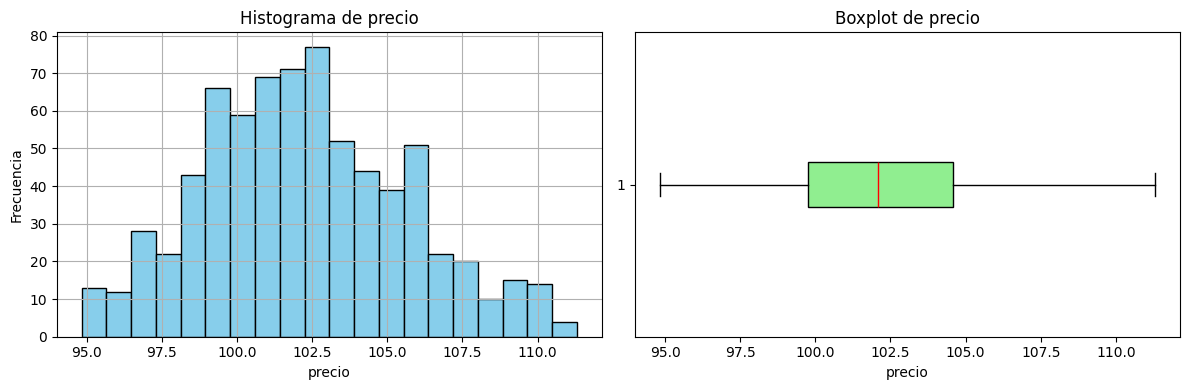

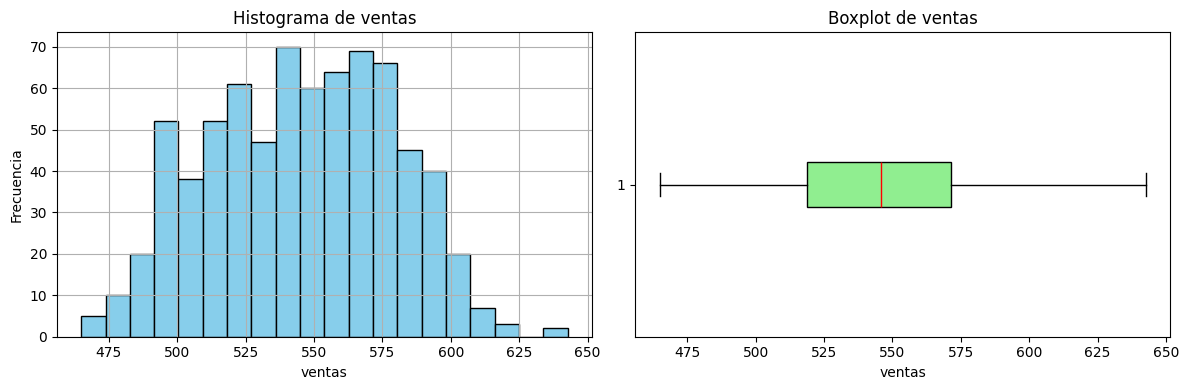

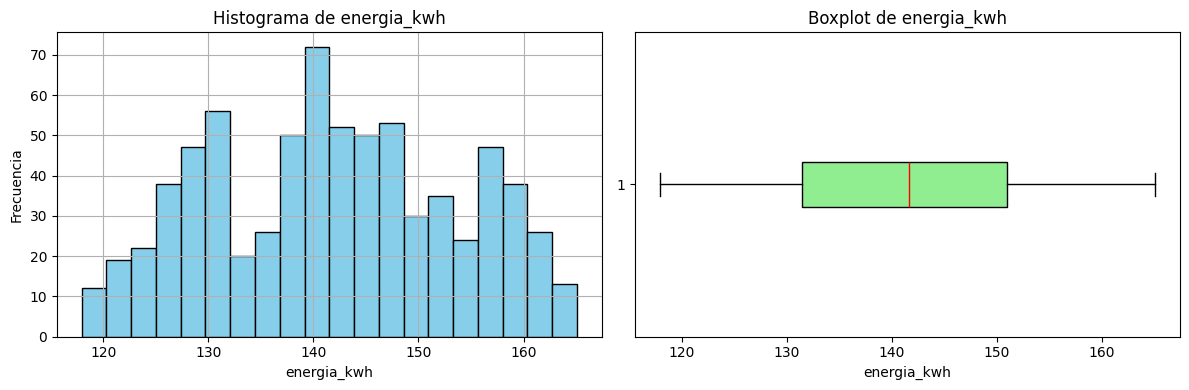

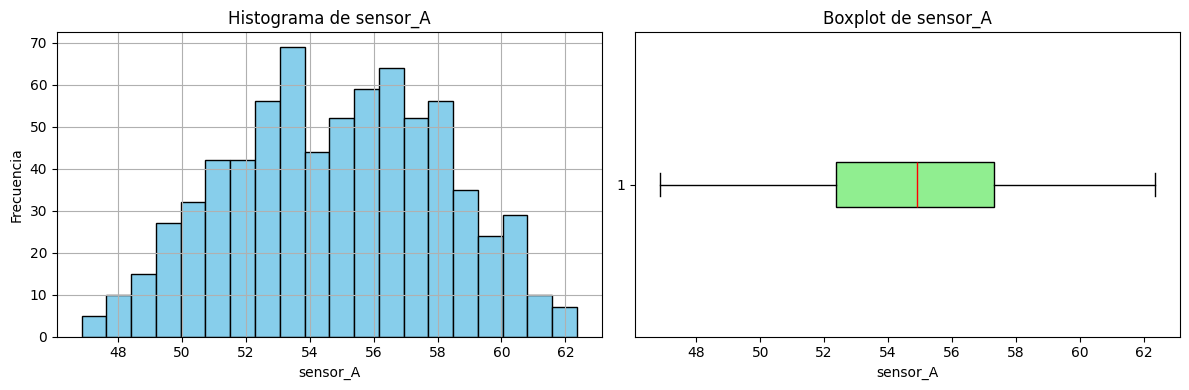

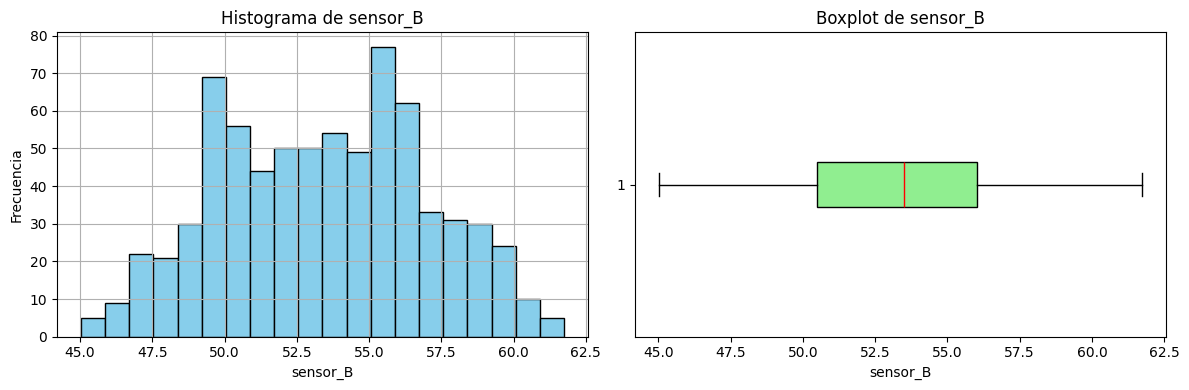

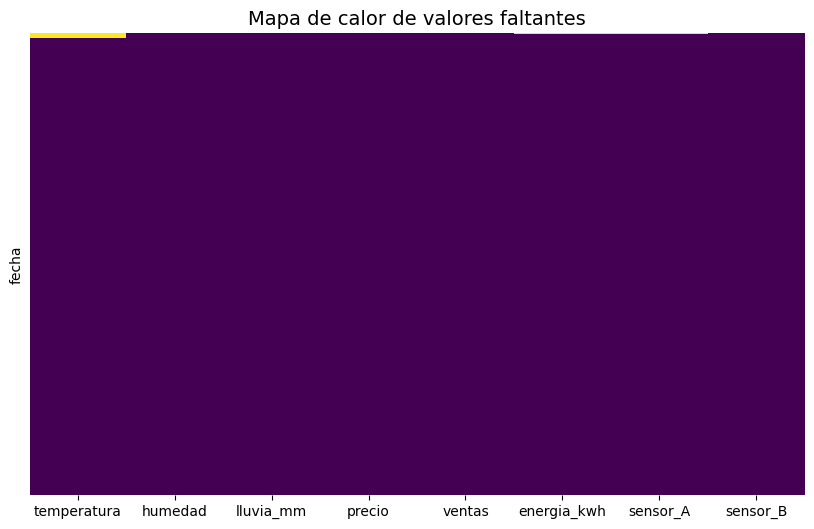

In [123]:
eda(df_ffill)

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,8,7,0



Encabezado:


,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
fecha,,,,,,,,
2023-01-01,21.38,60.67,0.00,99.68,527.2,120.04,50.476,51.647
2023-01-02,21.38,48.96,0.00,100.50,493.7,120.04,50.476,48.778
2023-01-03,21.38,48.73,0.00,100.86,487.7,119.11,52.349,48.953
2023-01-04,21.38,57.13,0.00,101.74,512.8,120.71,50.400,49.383
2023-01-05,21.38,55.49,2.79,101.77,477.4,119.39,50.400,46.964


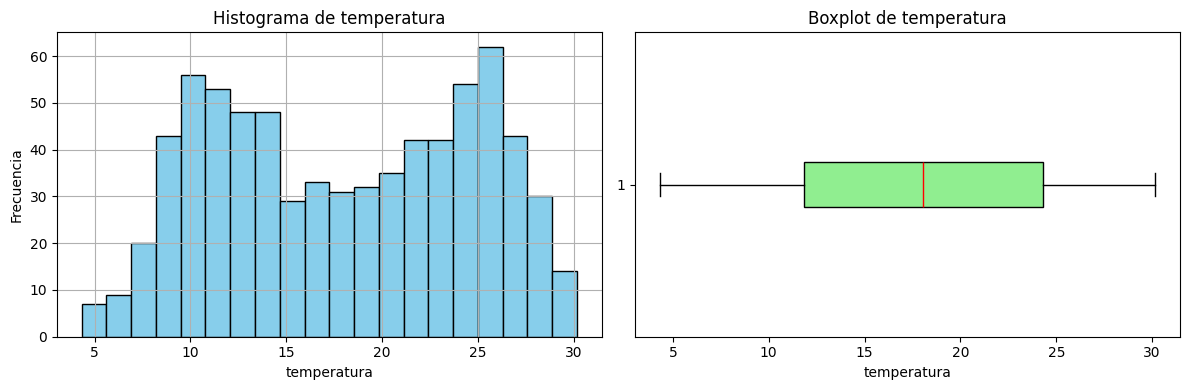

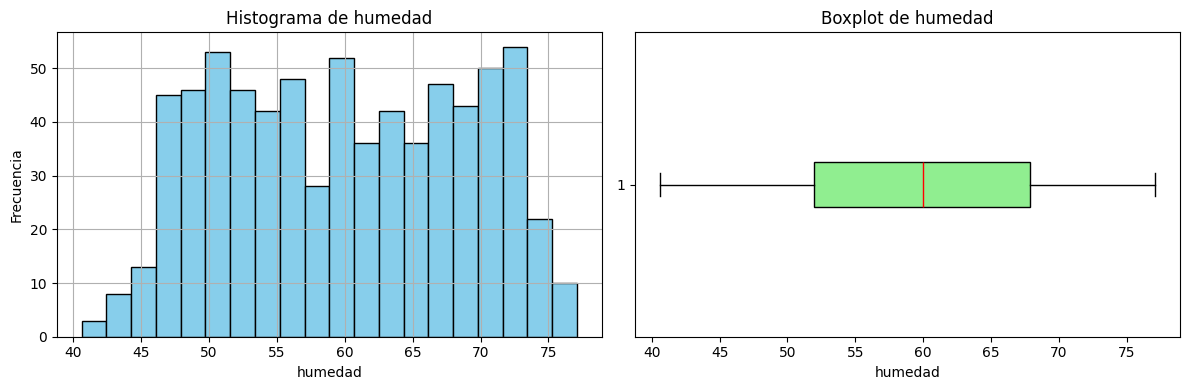

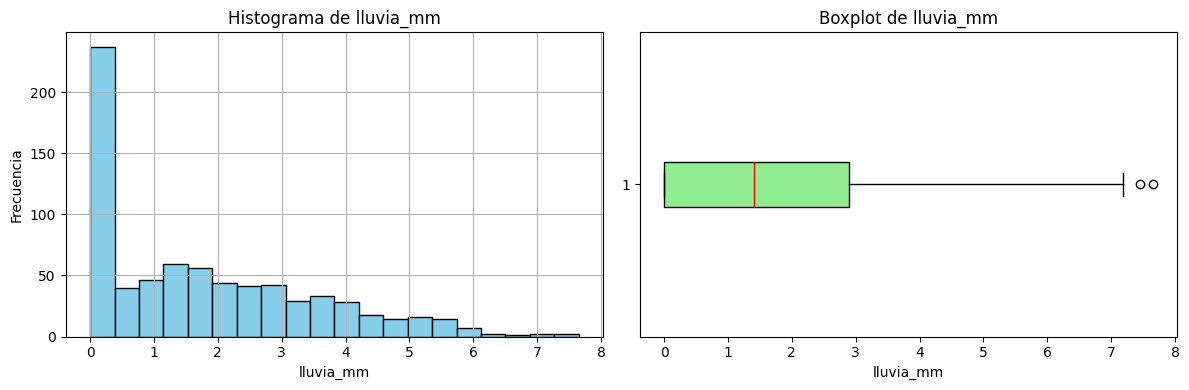

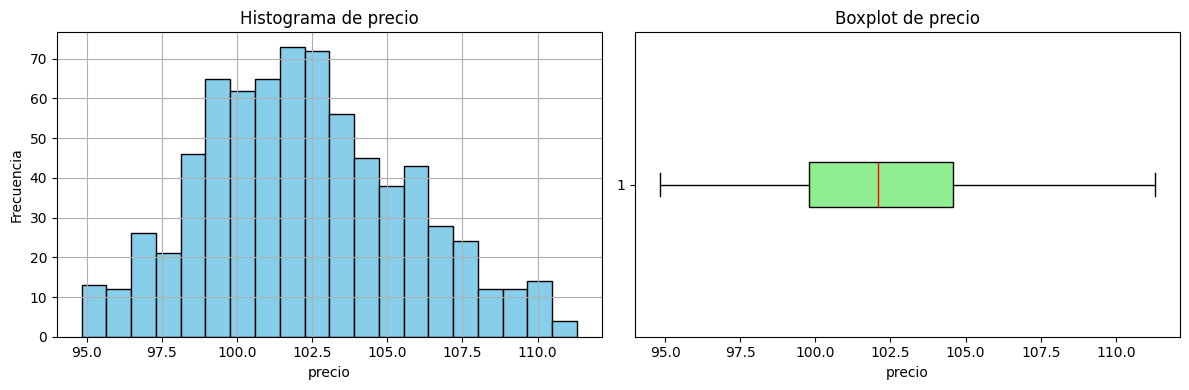

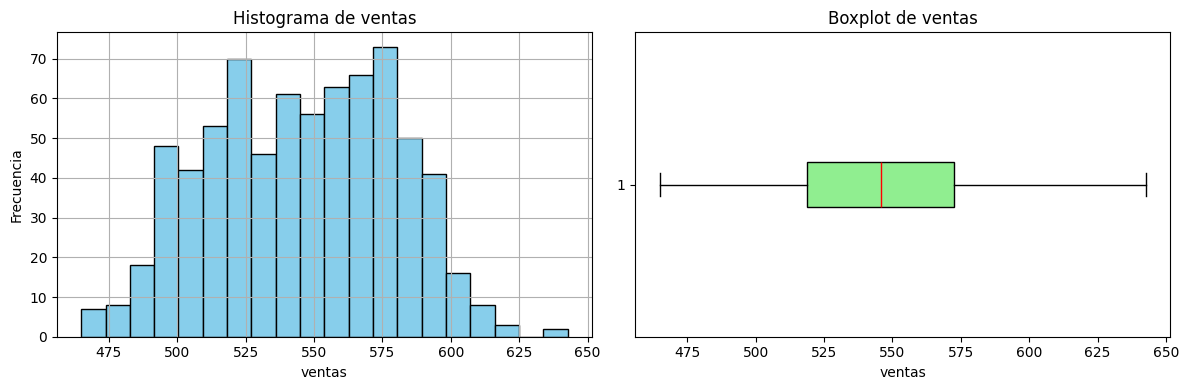

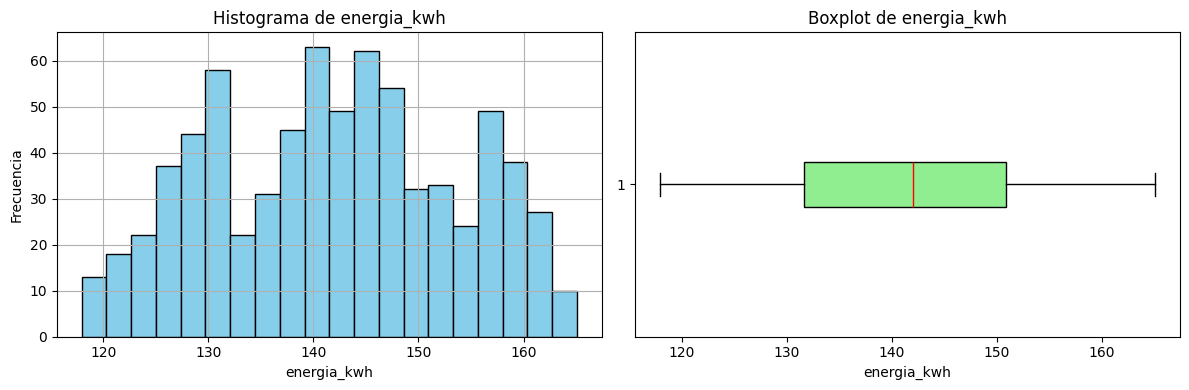

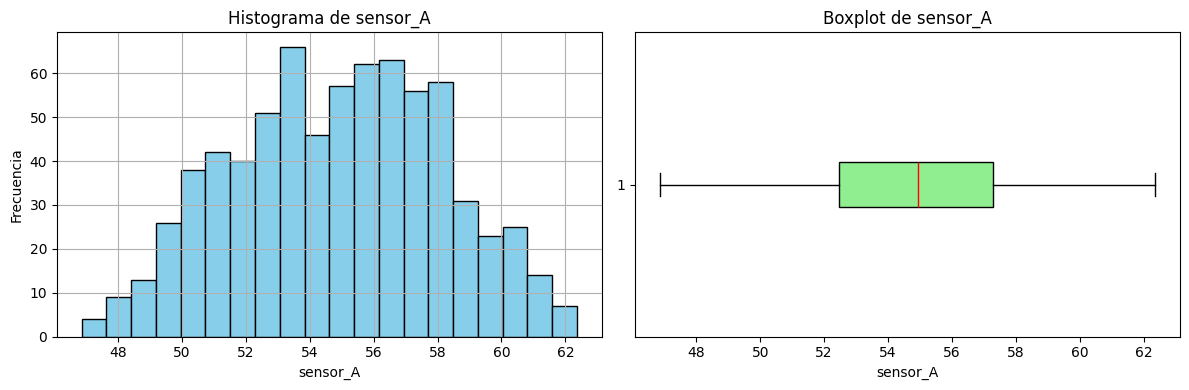

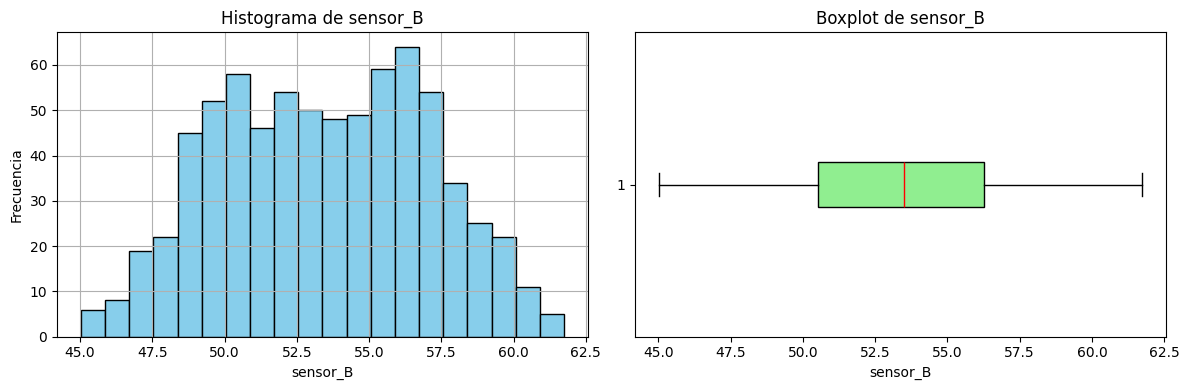

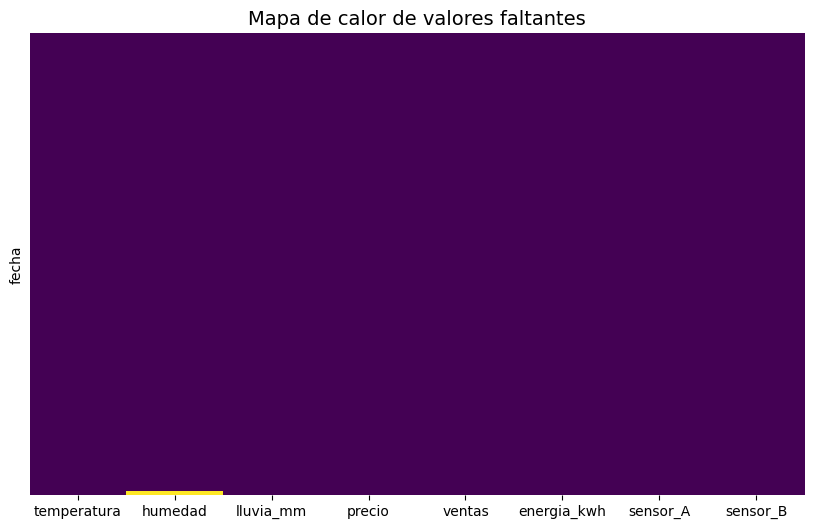

In [124]:
eda(df_bfill)

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,8,9,0



Encabezado:


,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
fecha,,,,,,,,
2023-01-01,NaN,60.67,0.00,99.68,527.2,NaN,NaN,51.647
2023-01-02,NaN,48.96,0.00,100.50,493.7,120.04,50.47600,48.778
2023-01-03,NaN,48.73,0.00,100.86,487.7,119.11,52.34900,48.953
2023-01-04,NaN,57.13,0.00,101.74,512.8,120.71,51.86175,49.383
2023-01-05,NaN,56.31,2.79,101.77,477.4,119.39,51.37450,46.964


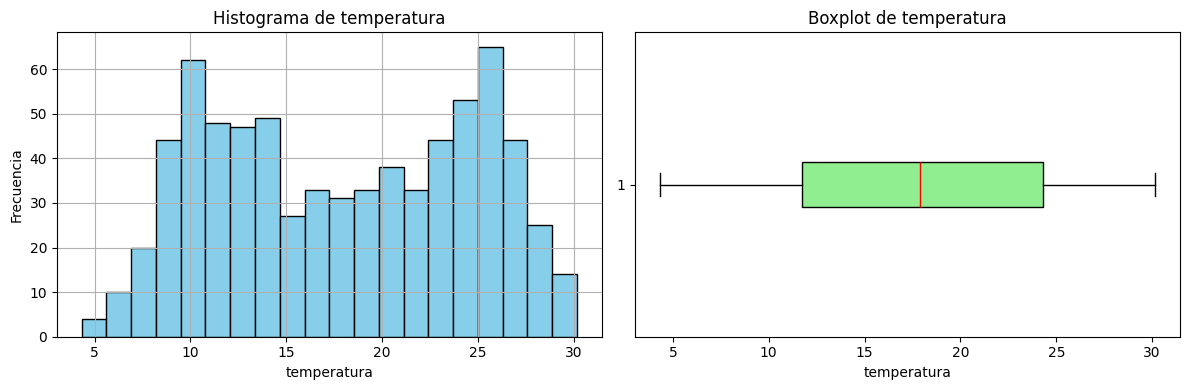

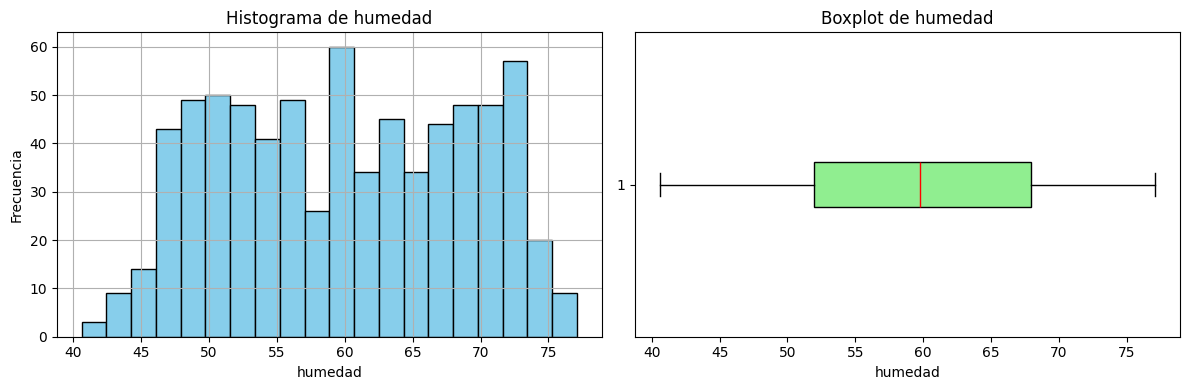

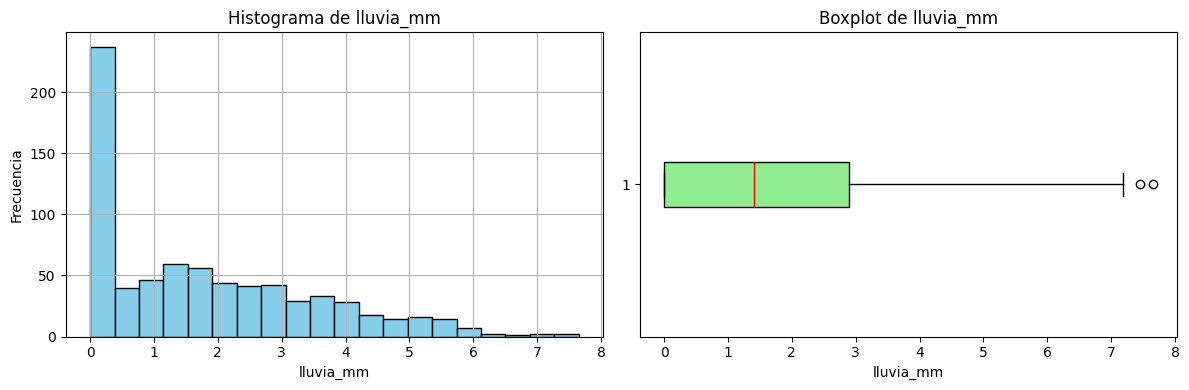

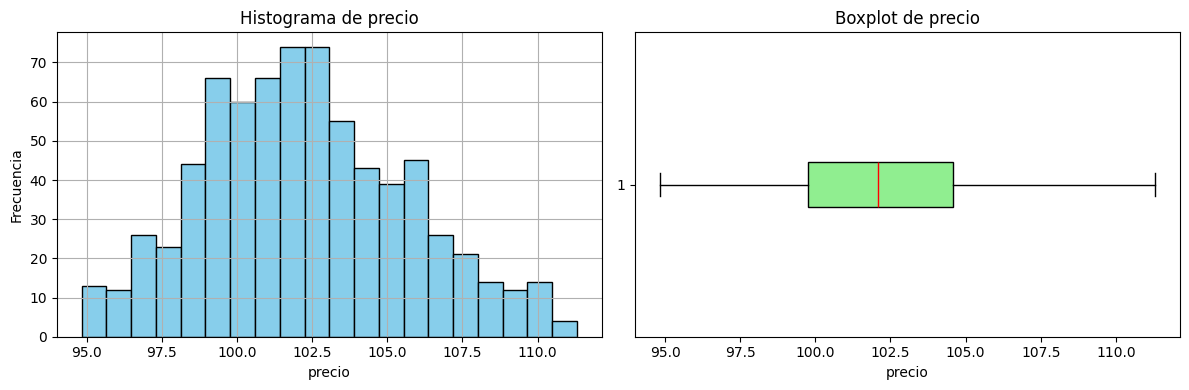

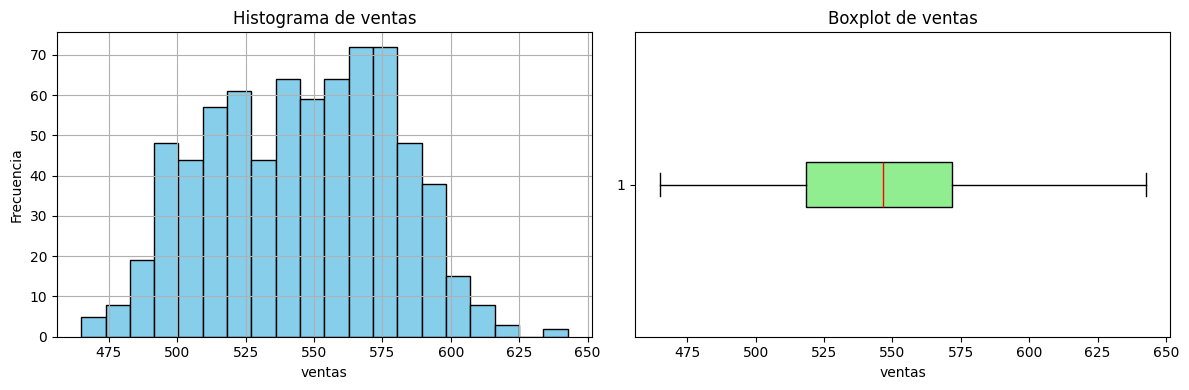

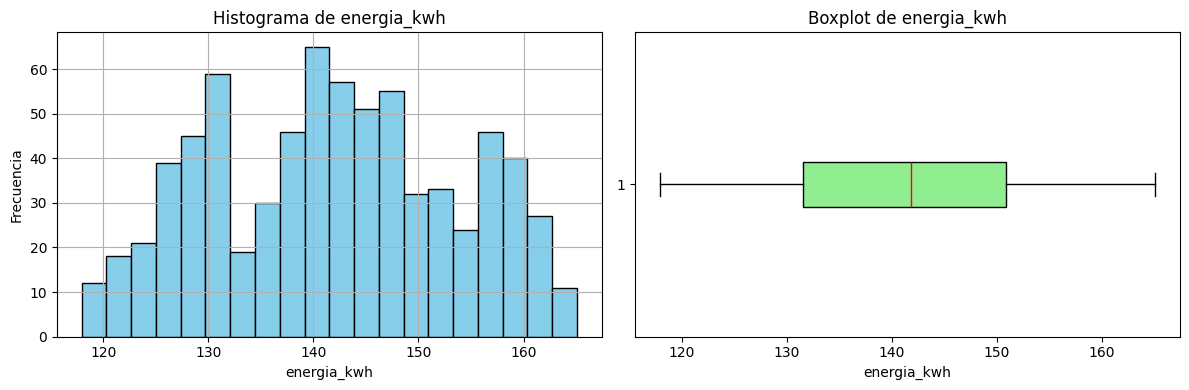

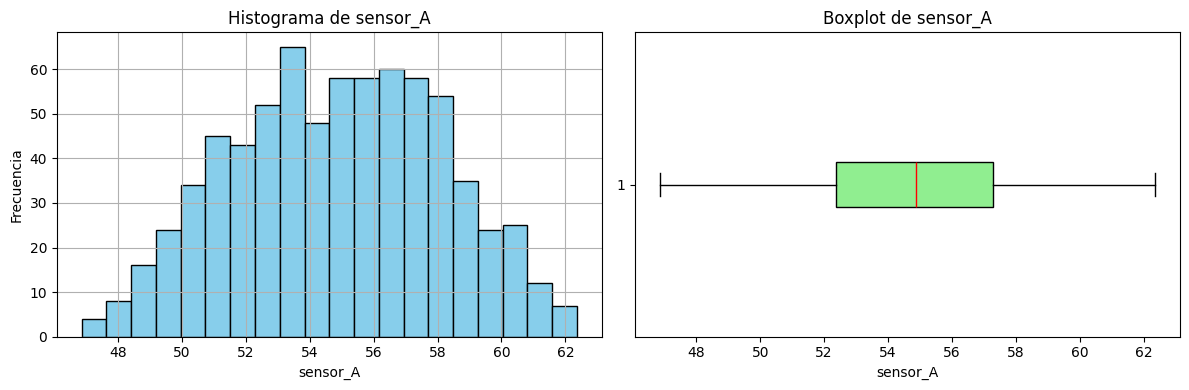

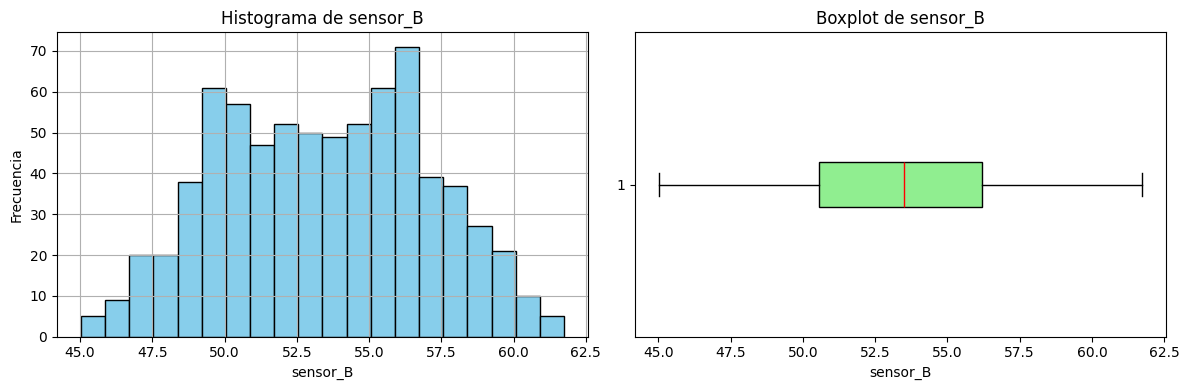

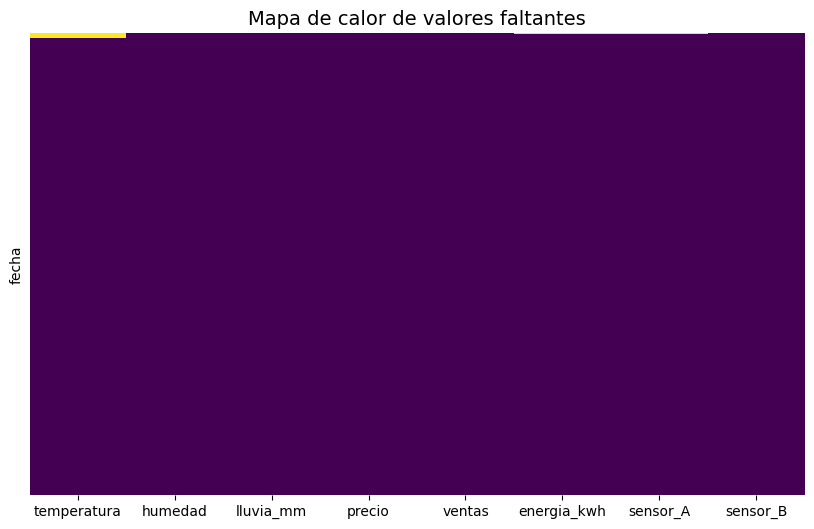

In [125]:
eda(df_interp)

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,8,9,0



Encabezado:


,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
fecha,,,,,,,,
2023-01-01,NaN,60.67,0.00,99.68,527.2,NaN,NaN,51.647
2023-01-02,NaN,48.96,0.00,100.50,493.7,120.04,50.47600,48.778
2023-01-03,NaN,48.73,0.00,100.86,487.7,119.11,52.34900,48.953
2023-01-04,NaN,57.13,0.00,101.74,512.8,120.71,51.86175,49.383
2023-01-05,NaN,56.31,2.79,101.77,477.4,119.39,51.37450,46.964


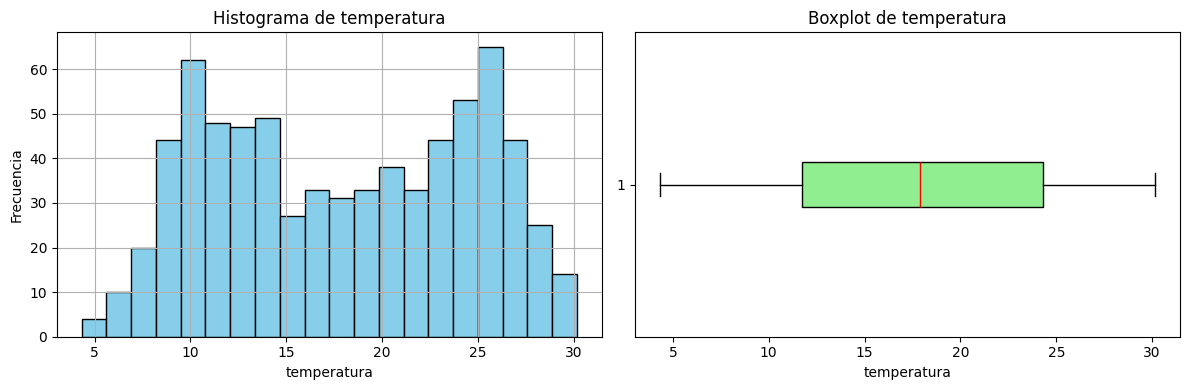

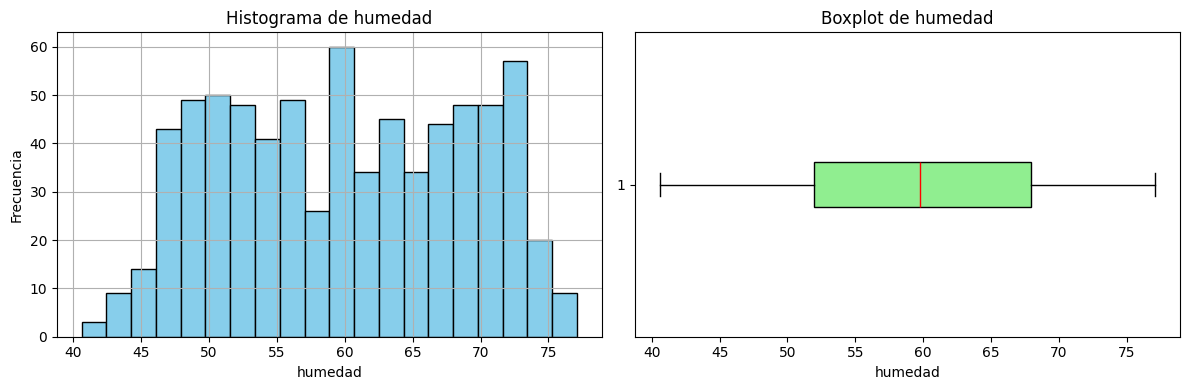

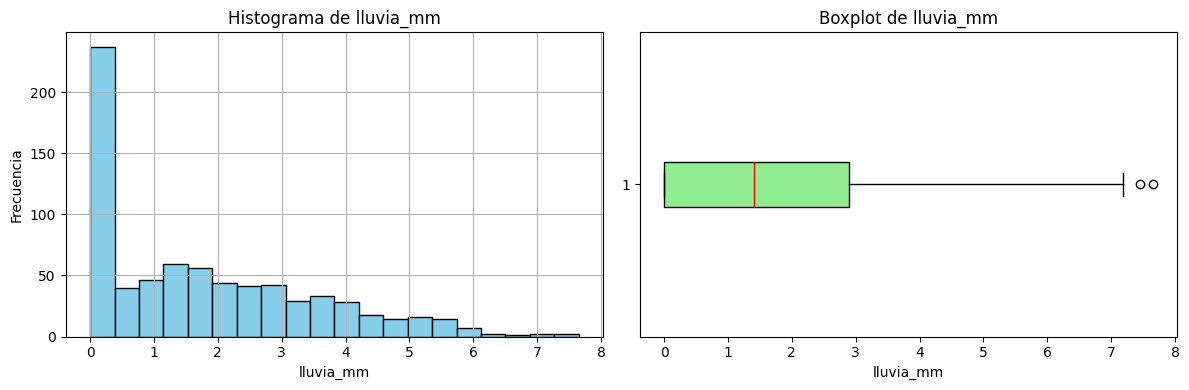

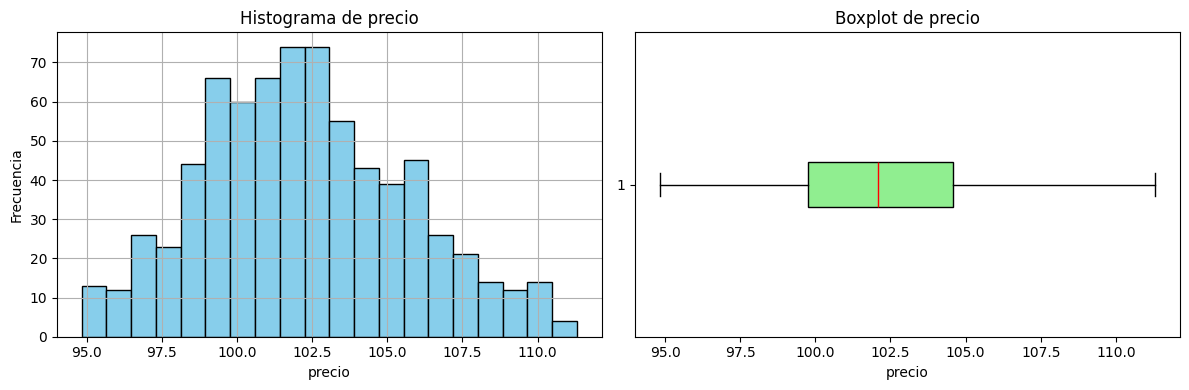

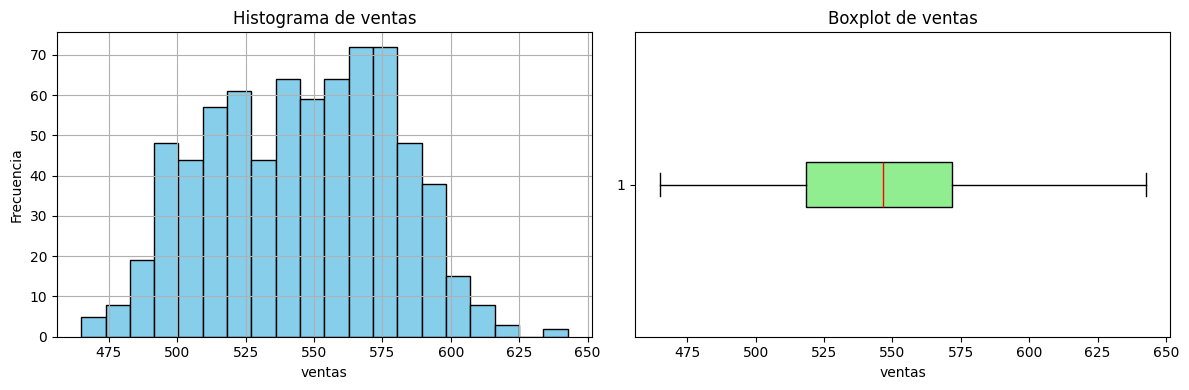

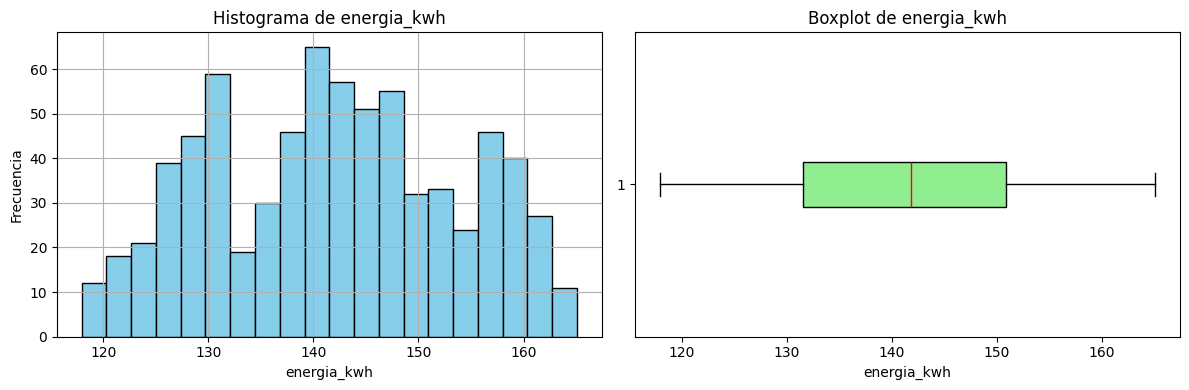

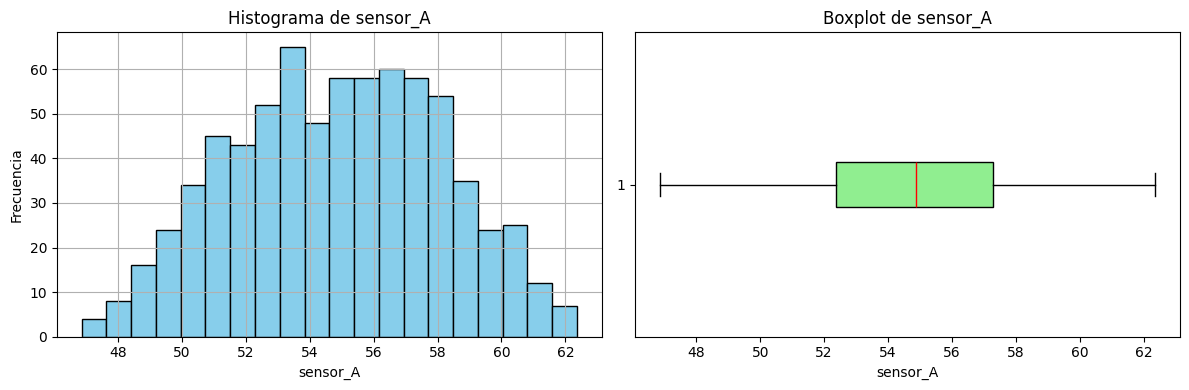

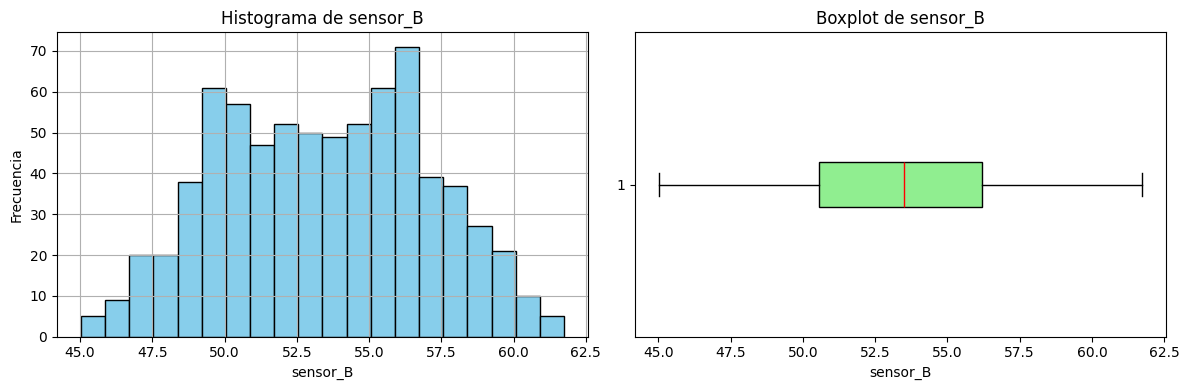

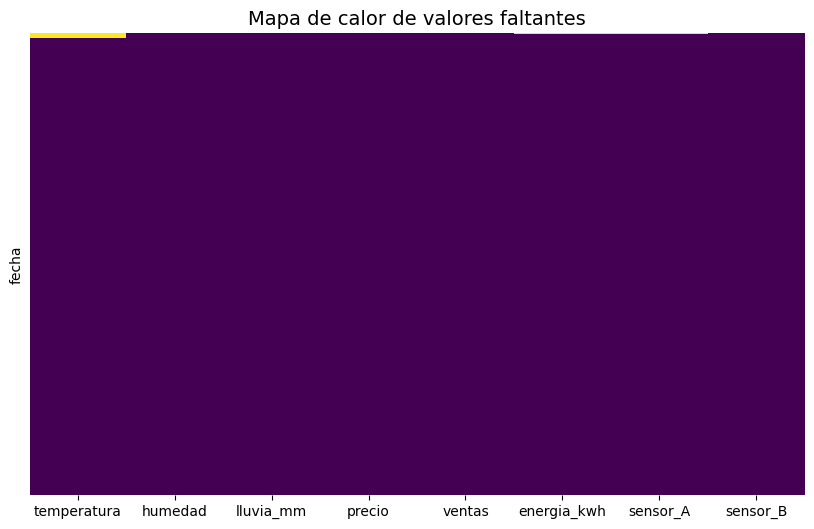

In [126]:
eda(df_time_interp)

Hoja: data

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,731,8,16,0



Encabezado:


,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
fecha,,,,,,,,
2023-01-01,NaN,60.670000,0.00,99.68,527.2,NaN,NaN,51.647
2023-01-02,NaN,48.960000,0.00,100.50,493.7,120.04,50.476000,48.778
2023-01-03,NaN,48.730000,0.00,100.86,487.7,119.11,52.349000,48.953
2023-01-04,NaN,57.130000,0.00,101.74,512.8,120.71,53.118966,49.383
2023-01-05,NaN,58.293464,2.79,101.77,477.4,119.39,52.785899,46.964


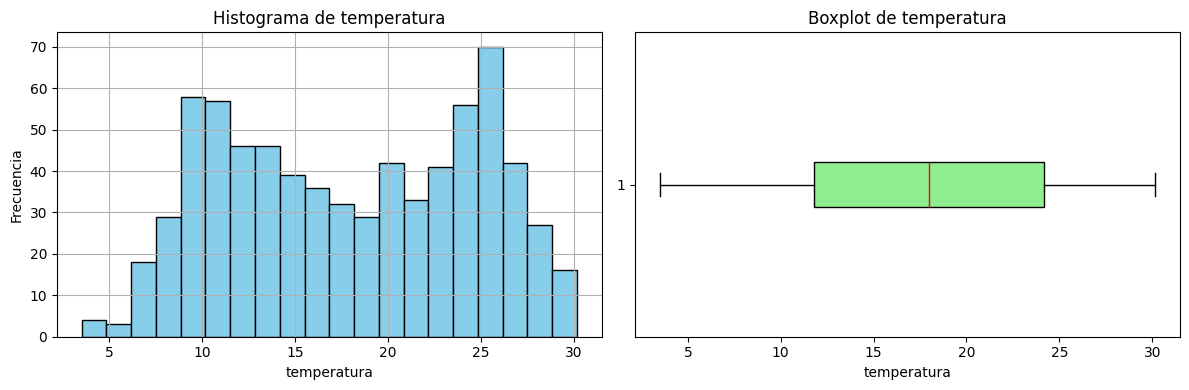

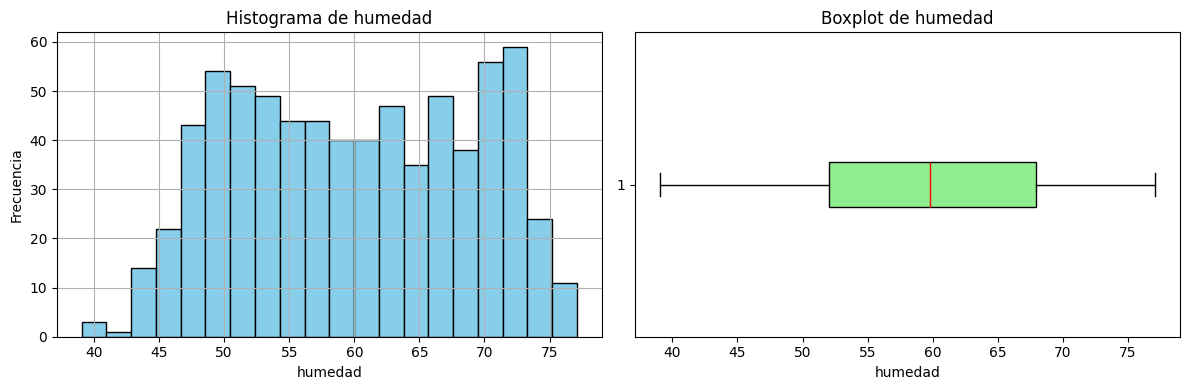

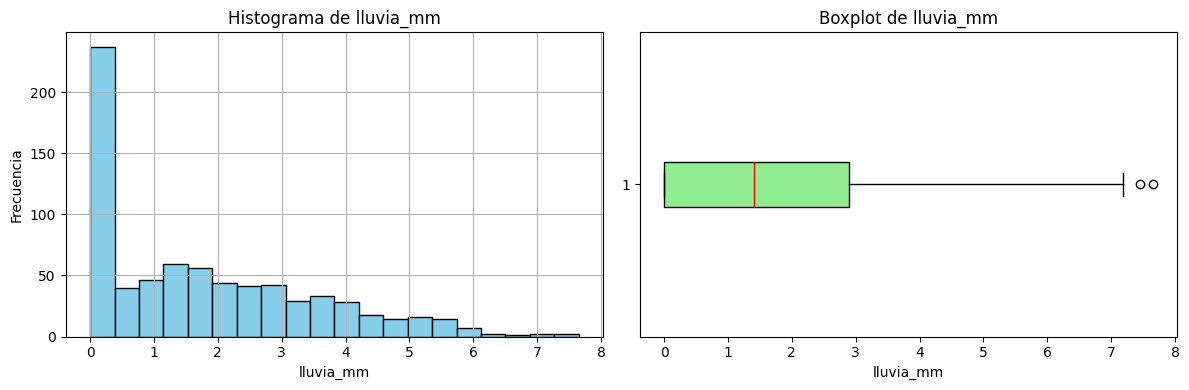

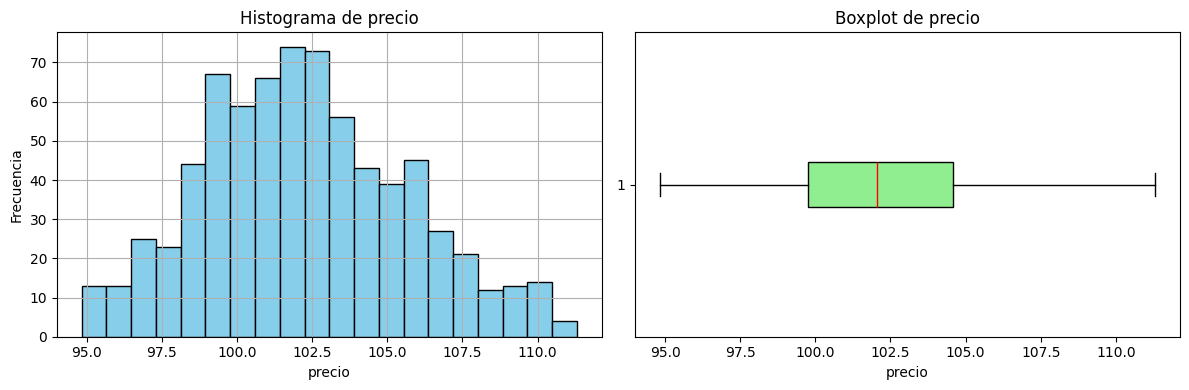

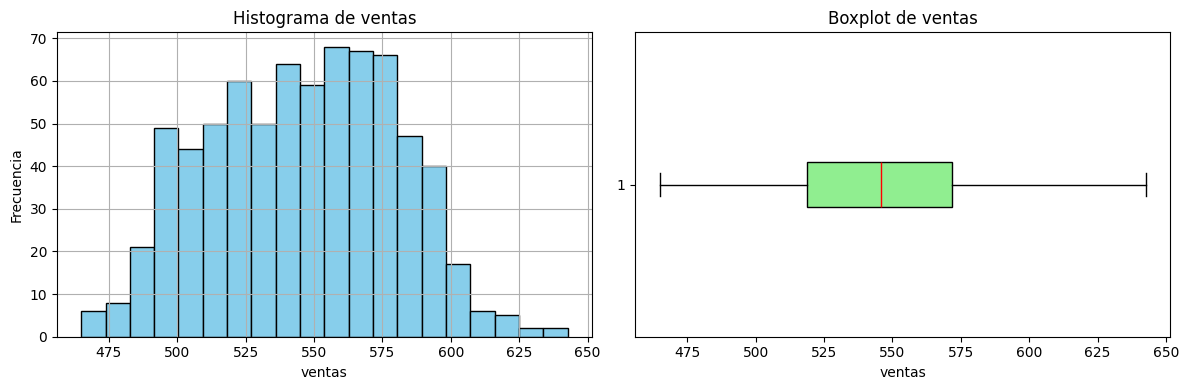

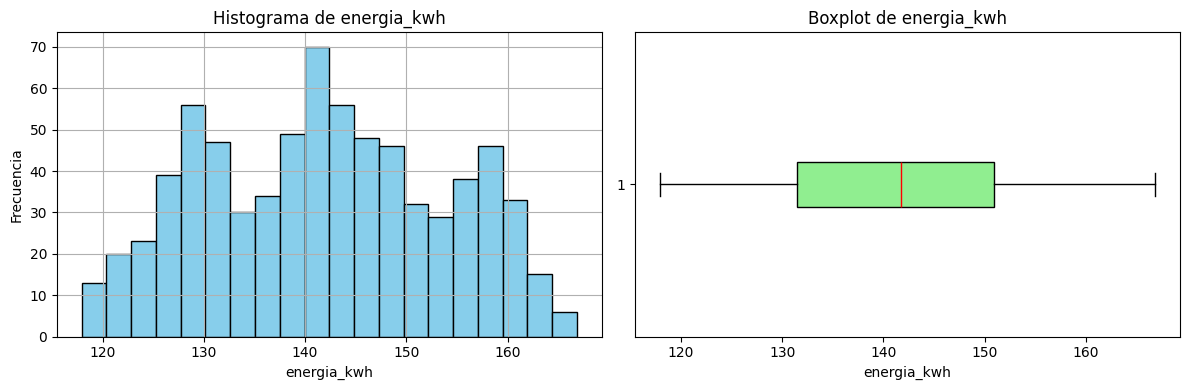

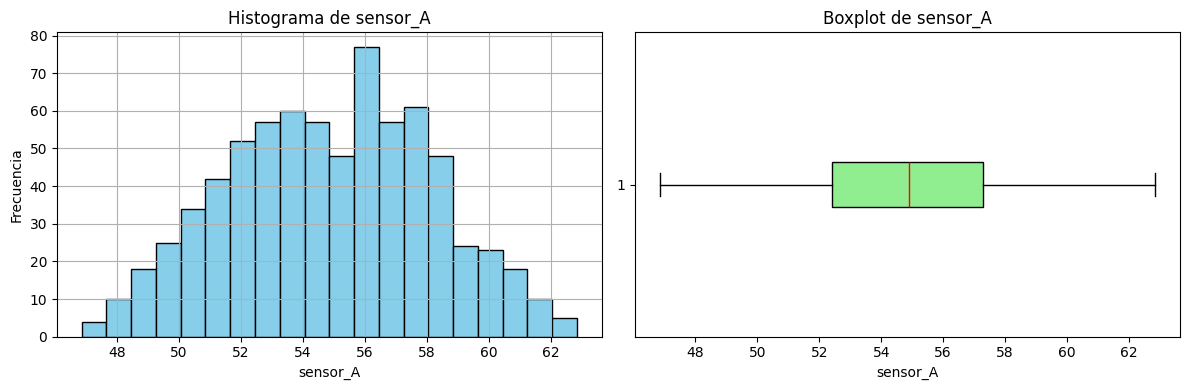

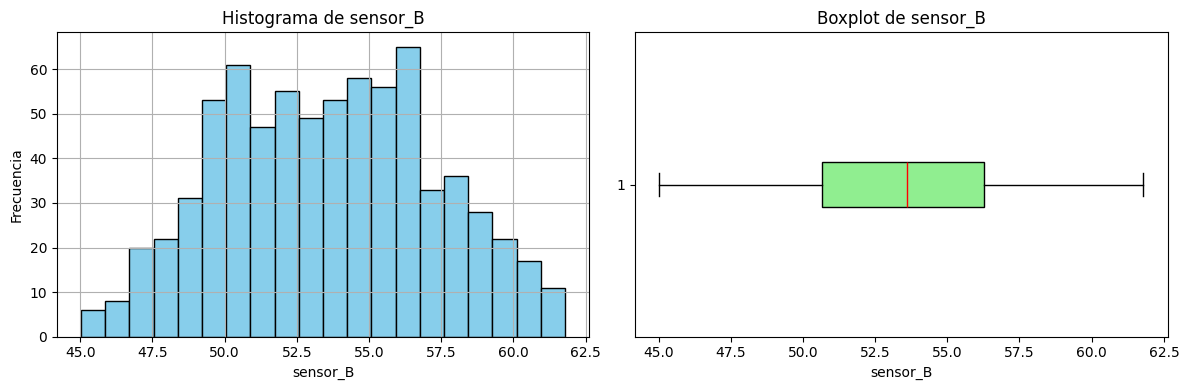

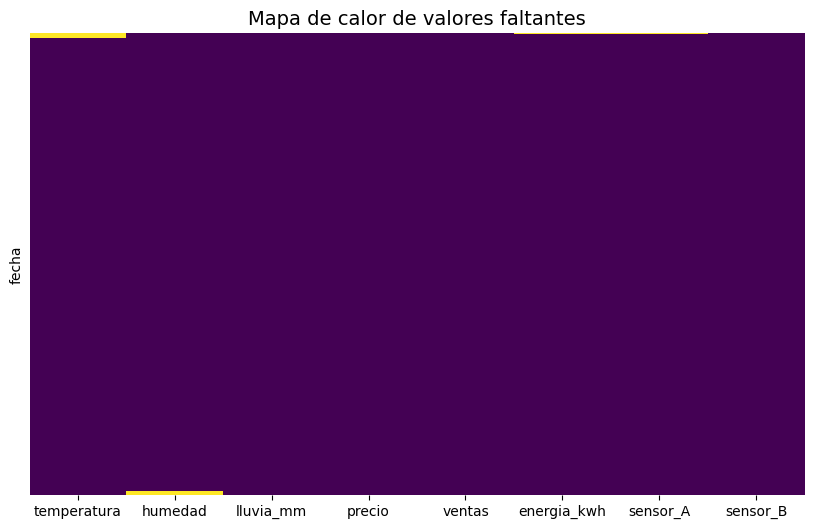

In [127]:
eda(df_poly)

### 